In [34]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from robusta_hmf import Robusta
import time
#%matplotlib widget

In [35]:
#define constants
c = 299792.458 # km/s
LN10 = np.log(10.)
MAX_IVAR = 2.5e3
MIN_IVAR = 0.1
H_ALPHA, H_BETA = 6564.614, 4862.721 #Reference: from classic.sdss.org
HE_I = 6680 #Reference: Johanna brain
HE_II = 4686 #Reference: Johanna brain

In [36]:
#read in the data and deal with radial velocities
with open('spectra_5021_2026-07-15_data.pkl','rb') as f:
     fluxes, loglam, ivars, continuua, spec_files, rvs, ews_halphas, nana_hash, parent_spectra = pickle.load(f)
print(fluxes.shape, loglam.shape, ivars.shape, continuua.shape, len(spec_files), rvs.shape, ews_halphas.shape, nana_hash.shape, parent_spectra.shape)

(5021, 4648) (4648,) (5021, 4648) (5021, 4648) 5021 (5021,) (5021,) (5021,) (5021, 846)


In [70]:
print(spec_files[:5])

['spec-019583-59629-27021598032036634.fits', 'spec-100553-59706-27021598682082428.fits', 'spec-100448-59827-27021598857671717.fits', 'spec-100461-59835-27021598839757494.fits', 'spec-100468-59907-27021598812099070.fits']


In [44]:
# remove spectra where Halpha equivalent width is negative (emission line)
good_ew_mask = ews_halphas >= 0

print(f"Keeping {good_ew_mask.sum()} / {len(good_ew_mask)} spectra (removed {(~good_ew_mask).sum()} with negative EW)")

fluxes = fluxes[good_ew_mask]
ivars = ivars[good_ew_mask]
continuua = continuua[good_ew_mask]
rvs = rvs[good_ew_mask]
ews_halphas = ews_halphas[good_ew_mask]
nana_hash = nana_hash[good_ew_mask]
spec_files = [sf for sf, keep in zip(spec_files, good_ew_mask) if keep]
parent_spectra = parent_spectra[good_ew_mask]

print(fluxes.shape, ivars.shape, continuua.shape, len(spec_files), rvs.shape, ews_halphas.shape, nana_hash.shape, parent_spectra.shape)

Keeping 4558 / 5021 spectra (removed 463 with negative EW)
(4558, 4648) (4558, 4648) (4558, 4648) 4558 (4558,) (4558,) (4558,) (4558, 846)


In [45]:
#load stellar parameters

df = pd.read_parquet("parent_stars_2026-07-15.parquet")
print("num of stars in parquet:", df.shape[0])

# print(df.columns.to_list())

num of stars in parquet: 35444


In [46]:
#log lambda values have been corrupted
print(10**loglam)
print(loglam[1:] - loglam[:-1])
print(np.median(loglam[1:] - loglam[:-1]))
delta_log_lambda_pixel = np.median(loglam[1:] - loglam[:-1])
wave = 10**loglam

[ 3566.9744  3567.795   3568.6177 ... 10394.412  10396.809  10399.206 ]
[9.9897385e-05 1.0013580e-04 9.9897385e-05 ... 1.0013580e-04 1.0013580e-04
 1.0013580e-04]
9.9897385e-05


In [47]:
#get ready to do pixel shifts
delta_log_lambdas = (rvs / c) / LN10
delta_pixels = np.round(delta_log_lambdas/delta_log_lambda_pixel).astype(int)

print(delta_log_lambdas, delta_pixels)

[1.18681209e-04 6.71403991e-05 5.35769155e-05 ... 6.13743152e-05
 8.74304321e-05 3.76062143e-05] [1 1 1 ... 1 1 0]


/var/folders/_f/c3__1v4j349bfc51yh6jhk_w0000gp/T/ipykernel_50356/442010926.py:3: RuntimeWarning: invalid value encountered in cast
  delta_pixels = np.round(delta_log_lambdas/delta_log_lambda_pixel).astype(int)


In [48]:
#shift spectra to the rest frame
## johanna is not going to like this

rest_fluxes = np.zeros_like(fluxes) + 1.
rest_ivars = np.zeros_like(ivars)
rest_continuua = np.zeros_like(continuua) + np.nan
for i, dp in enumerate(delta_pixels):
    if dp < 0:
        rest_fluxes[i, -dp:] = fluxes[i, :dp]
        rest_ivars[i, -dp:] = ivars[i, :dp]
        rest_continuua[i, -dp:] = continuua[i, :dp]
        
    elif dp > 0:
        rest_fluxes[i, :-dp] = fluxes[i, dp:]
        rest_ivars[i, :-dp] = ivars[i, dp:]
        rest_continuua[i, :-dp] = continuua[i, dp:]
        
    else:
        rest_fluxes[i, :] = fluxes[i, :]
        rest_ivars[i, :] = ivars[i, :]
        rest_continuua[i, :] = continuua[i, :]


In [49]:
#fix nans and infinities
bad = np.logical_not(np.isfinite(rest_fluxes))
rest_fluxes[bad] = 1
rest_ivars[bad] = 0

bad = np.logical_not(np.isfinite(rest_ivars))
rest_fluxes[bad] = 1
rest_ivars[bad] = 0

bad = np.logical_or((rest_fluxes > 2.0), (rest_fluxes < 0))
rest_fluxes[bad] = 1
rest_ivars[bad] = 0

bad = rest_ivars > MAX_IVAR
# rest_fluxes[bad] = 1
# rest_ivars[bad] = 0
rest_ivars[bad] = MAX_IVAR

bad = ivars < MIN_IVAR
rest_fluxes[bad] = 1.0
rest_ivars[bad] = MIN_IVAR

In [42]:
#we are using the rest frame data as our data 
data = rest_fluxes
weights = rest_ivars

In [50]:
# split data to A and B using nana_hash parity, only train on A
N, M = fluxes.shape

Aindx = np.where(nana_hash % 2 == 0)[0]
Bindx = np.where(nana_hash % 2 == 1)[0]

print(f"A: {len(Aindx)} spectra, B: {len(Bindx)} spectra")

# hyperparameters set here
K = 12
modelA = Robusta(rank=K, robust=True, robust_scale=1, robust_nu=1)
start = time.perf_counter()
modelA.fit(data[Aindx], weights[Aindx], max_iter=10000)
end = time.perf_counter()
print("total time:", (end - start)/60, "minutes")

A: 2336 spectra, B: 2222 spectra
Initializing state... done.
iter 011 | loss 2894141.8201
iter 021 | loss 2889965.1020
iter 031 | loss 2888598.6529
iter 041 | loss 2887293.6485
iter 051 | loss 2886041.1160
iter 061 | loss 2885177.1928
iter 071 | loss 2884725.1129
iter 081 | loss 2884520.8187
iter 091 | loss 2884401.4917
iter 101 | loss 2884093.7143
iter 111 | loss 2883987.0758
iter 121 | loss 2883891.6124
iter 131 | loss 2883852.4427
iter 141 | loss 2883803.1239
iter 151 | loss 2883685.5478
iter 161 | loss 2883539.5989
iter 171 | loss 2883394.9910
iter 181 | loss 2883194.7236
iter 191 | loss 2882503.3032
iter 201 | loss 2881411.5231
iter 211 | loss 2880149.0671
iter 221 | loss 2879257.7937
iter 231 | loss 2879036.6335
iter 241 | loss 2878987.7307
iter 251 | loss 2878932.2901
iter 261 | loss 2878915.1609
iter 271 | loss 2878914.2508
iter 281 | loss 2878913.8637
iter 291 | loss 2878913.3557
iter 301 | loss 2878911.9067
iter 311 | loss 2878911.2812
iter 321 | loss 2878911.2465
iter 331 | 

In [51]:
# synthesize, but masking Balmer lines.
log_H_ALPHA, log_H_BETA, log_HE_I, log_HE_II = np.log10(H_ALPHA), np.log10(H_BETA), np.log10(HE_I), np.log10(HE_II)

H_delta_lnlam_line = 1000 / c # km/s, this is the v/c ratio notice must be natural log for ln(x + 1) ≈ x to hold
H_delta_loglam_line = H_delta_lnlam_line / LN10 #convert to log10 units must match!!
region_alpha = np.abs(loglam - log_H_ALPHA)
region_beta = np.abs(loglam - log_H_BETA)

#do the same but half width of 500km/s for helium lines
HE_delta_lnlam_line = 500 / c
HE_delta_loglam_line = HE_delta_lnlam_line / LN10
region_he_i = np.abs(loglam - log_HE_I)
region_he_ii = np.abs(loglam - log_HE_II)


censor_mask = np.ones_like(loglam)
censor_mask[(region_alpha < H_delta_loglam_line) | (region_beta < H_delta_loglam_line) 
          | (region_he_i < HE_delta_loglam_line) | (region_he_ii < HE_delta_loglam_line)] = 0 #?

state, _ = modelA.infer(data[Bindx], weights[Bindx] * censor_mask[None, :])
synth_B = modelA.synthesize(state)

iter 011 | loss 2697060.0531
Converged at iteration 20


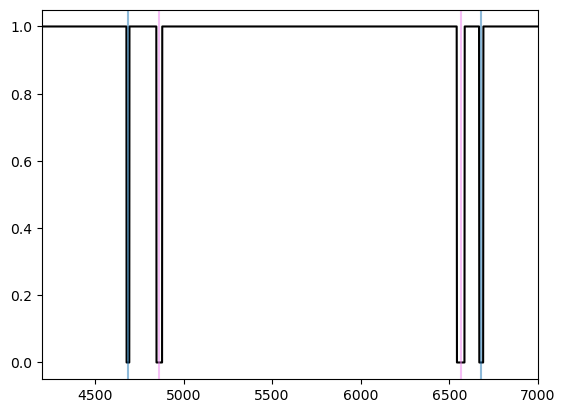

In [52]:
# check that mask is not wrong
plt.plot(10**loglam, censor_mask, 'k')
plt.axvline(H_ALPHA, alpha = 0.5, color = 'violet')
plt.axvline(H_BETA, alpha = 0.5, color = 'violet')
plt.axvline(HE_I, alpha = 0.5)
plt.axvline(HE_II, alpha = 0.5)
plt.xlim(4200,7000)
plt.show()

## Eigenspectra Plotting

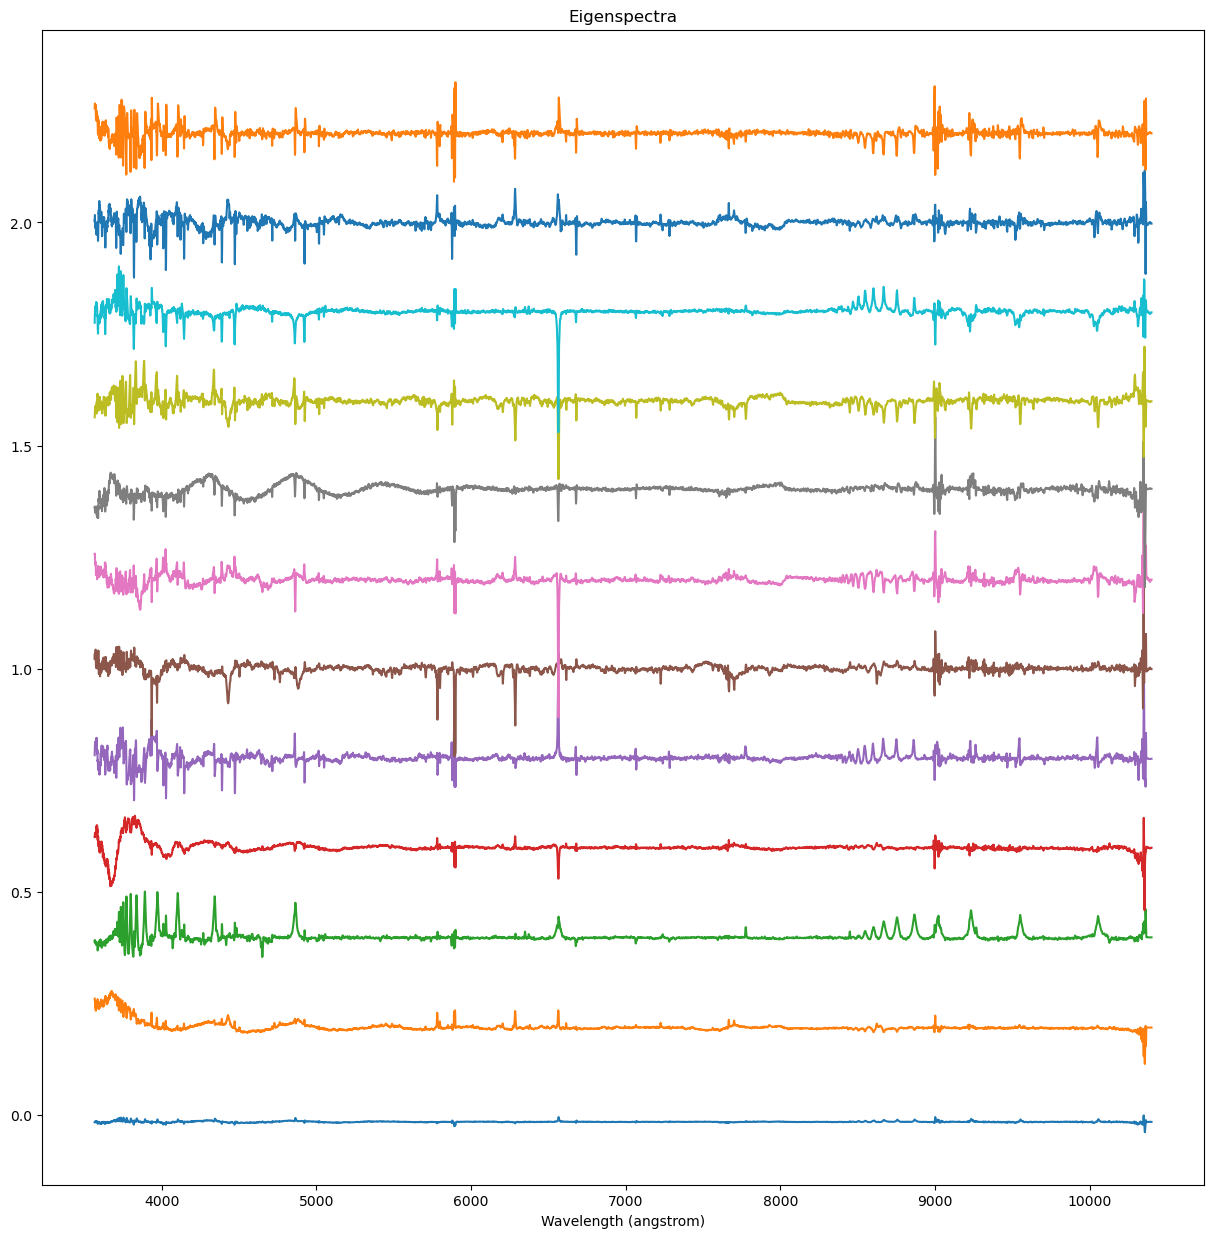

In [53]:
eigsA = modelA.basis_vectors().T

f = plt.figure(figsize=(15, 15))
plt.title("Eigenspectra")
offset = 0.2
for i in range(K):
    f.gca().plot(wave, eigsA[i] + i * offset)

#plt.axvline(H_ALPHA, lw=1, alpha=0.5, color="blue")
plt.xlabel("Wavelength (angstrom)")
plt.show()

## Synthesized Spectra Examples

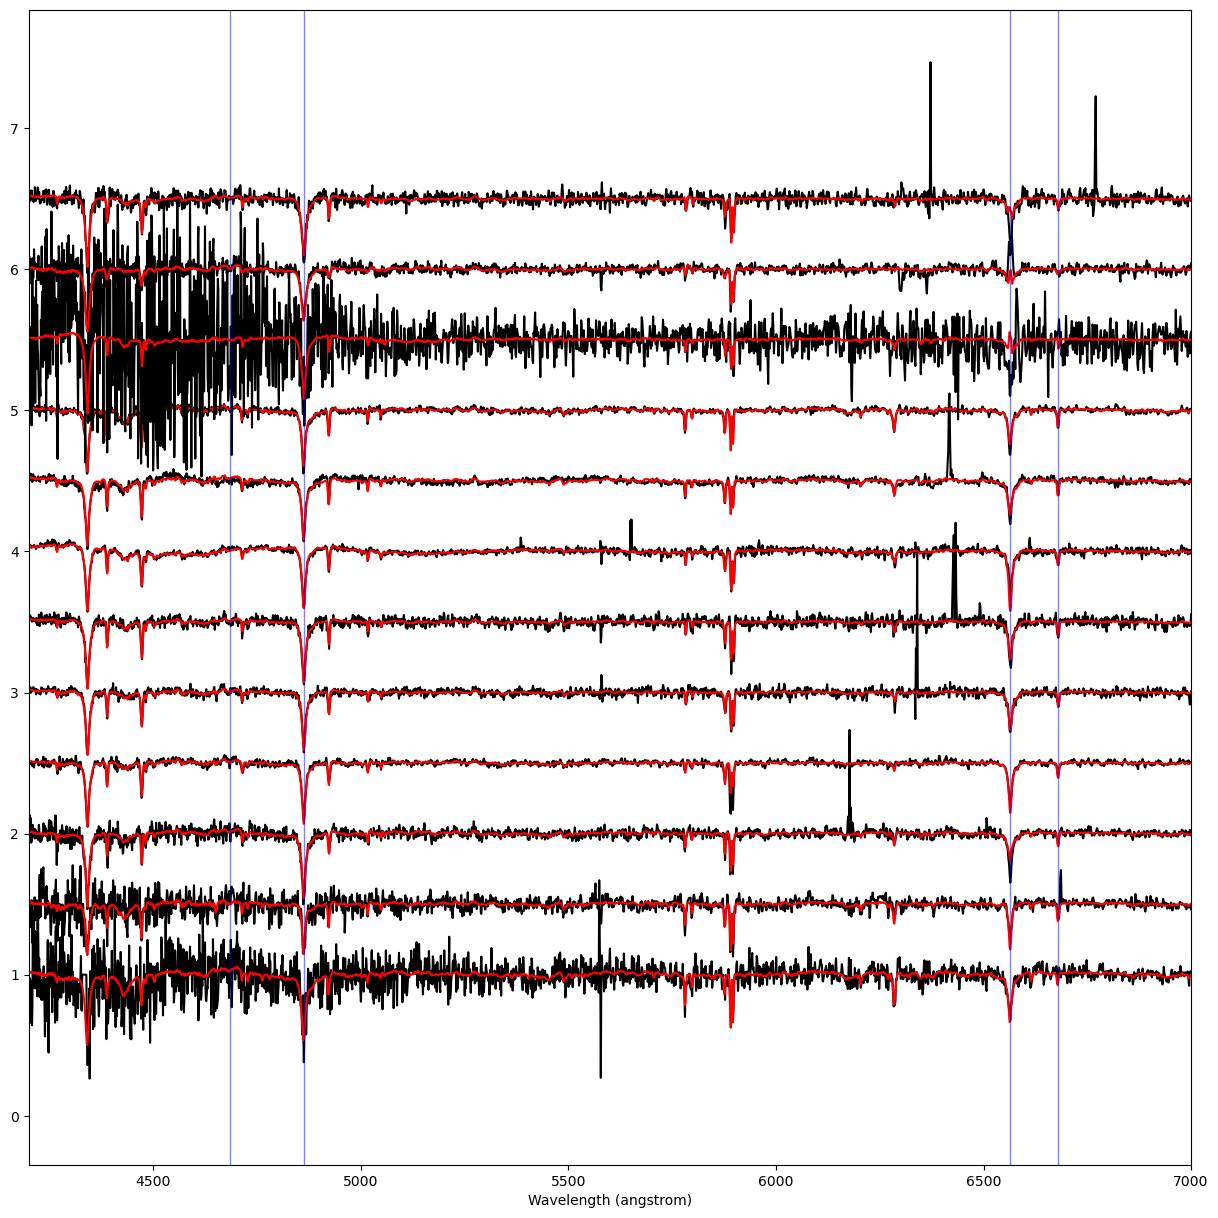

In [54]:
# look at a few spectra and syntheses
f = plt.figure(figsize=(15, 15))
offset = 0.5
for i in range(12):
    f.gca().plot(wave, data[Bindx[i]] + i * offset, color="k")
    f.gca().plot(wave, synth_B[i] + i * offset, color="r")

plt.axvline(H_ALPHA, lw=1, alpha=0.5, color="b")
plt.axvline(H_BETA, lw=1, alpha=0.5, color="b")
plt.axvline(HE_I, lw=1, alpha=0.5, color="b")
plt.axvline(HE_II, lw=1, alpha=0.5, color="b")
plt.xlim(4200, 7000)
plt.xlabel("Wavelength (angstrom)")
plt.show()

## Residual Examples

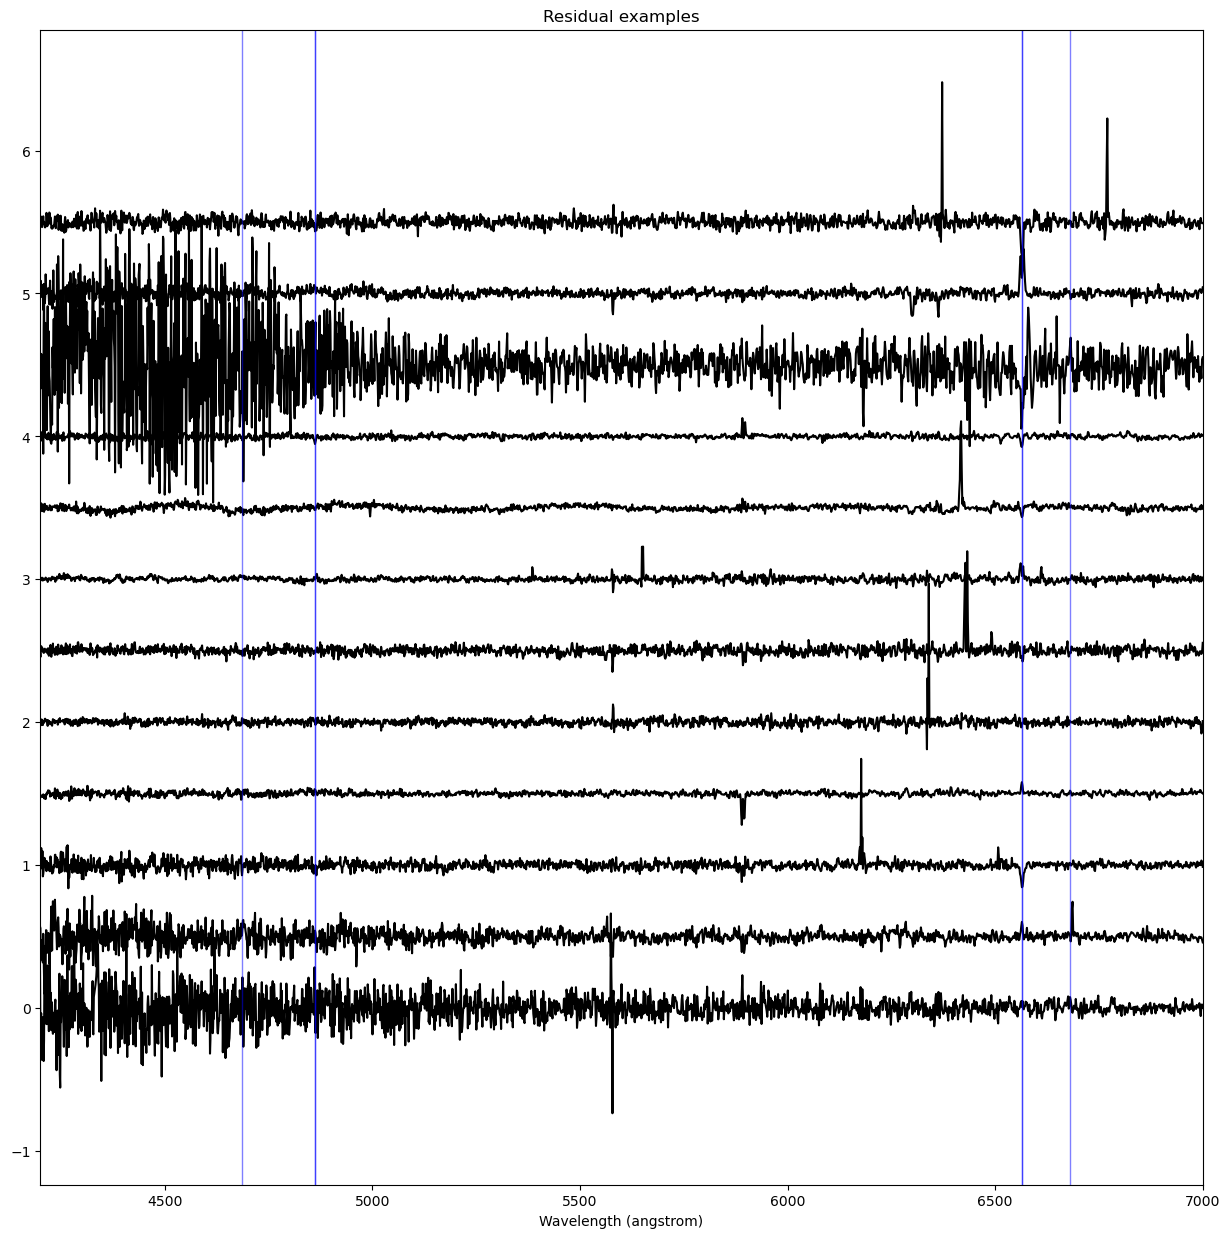

In [55]:
# look at residuals at H-alpha
f = plt.figure(figsize=(15, 15))
offset = 0.5
for i in range(12):
    f.gca().plot(wave, data[Bindx[i]] + i * offset - synth_B[i], color="k")

plt.axvline(H_ALPHA, lw=1, alpha=0.5, color="b")
plt.axvline(H_BETA, lw=1, alpha=0.5, color="b")
plt.xlabel("Wavelength (angstrom)")
#plt.xlim(H_ALPHA - 200., H_ALPHA + 200.)
plt.title("Residual examples")
plt.axvline(H_ALPHA, lw=1, alpha=0.5, color="b")
plt.axvline(H_BETA, lw=1, alpha=0.5, color="b")
plt.axvline(HE_I, lw=1, alpha=0.5, color="b")
plt.axvline(HE_II, lw=1, alpha=0.5, color="b")
plt.xlim(4200, 7000)
plt.show()

### measure equivalent widths

In [57]:
#Recall how we defined some stuff in the censor masking section
# H_delta_lnlam_line = 1000 / c #1000km/s half width for H_ALPHA, H_BETA
# H_delta_loglam_line = H_delta_lnlam_line / LN10 
# HE_delta_lnlam_line = 500 / c #500km/s half width for HE_I, HE_II
# HE_delta_loglam_line = HE_delta_lnlam_line / LN10


lam = 10 ** loglam
N, M = data[Bindx].shape
lines = [H_ALPHA, H_BETA, HE_I, HE_II]  
#make sure half_widths and lines match!!!!!!
half_wids = [H_delta_loglam_line, H_delta_loglam_line, HE_delta_loglam_line, HE_delta_loglam_line] 
ews = np.zeros((N, len(lines))) + np.nan

for j, (line, wid) in enumerate(zip(lines, half_wids)):
    logline = np.log10(line)
    integration_weight = delta_log_lambda_pixel * LN10 * lam * (np.abs(logline - loglam) < wid)
    ews[:, j] = np.sum((data[Bindx] - synth_B) * integration_weight[None, :], axis=1)

## Scatter Plots of EWS

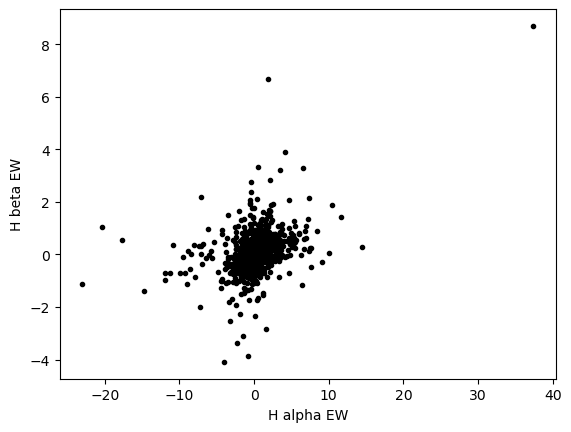

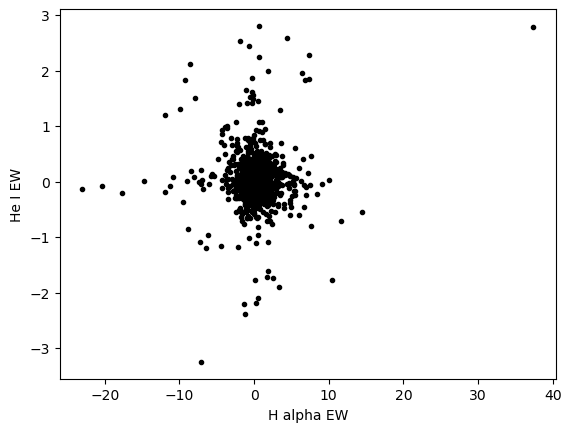

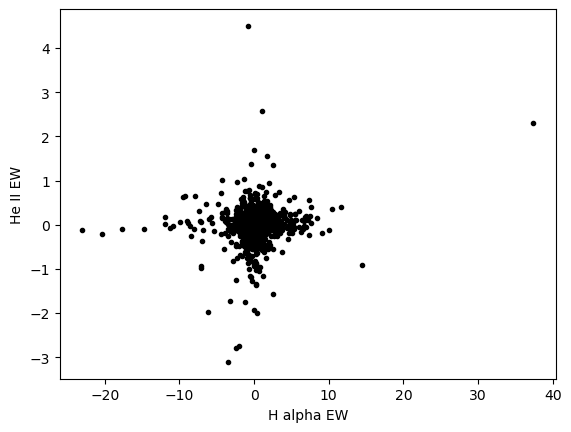

In [58]:
plt.plot(ews[:, 0], ews[:, 1], "k.")
plt.xlabel("H alpha EW")
plt.ylabel("H beta EW")
plt.show()

plt.plot(ews[:, 0], ews[:, 2], "k.")
plt.xlabel("H alpha EW")
plt.ylabel("He I EW")
plt.show()

plt.plot(ews[:, 0], ews[:, 3], "k.")
plt.xlabel("H alpha EW")
plt.ylabel("He II EW")
plt.show()

## Sorted by highest EW, Residuals

spec-100580-60542-63050394949280317.fits
spec-104420-61025-63050394999313068.fits
spec-103691-60605-63050394803399944.fits
spec-106739-60392-63050396406961072.fits
spec-100194-60597-63050394785355017.fits
spec-112241-60752-63050396142608402.fits
spec-103685-60245-63050394804354206.fits
spec-104416-60246-63050394975127704.fits
spec-100600-60276-63050394945143660.fits
spec-103475-60654-63050395132670898.fits
spec-105818-60665-63050395877604362.fits
spec-109931-60542-63050395328394571.fits


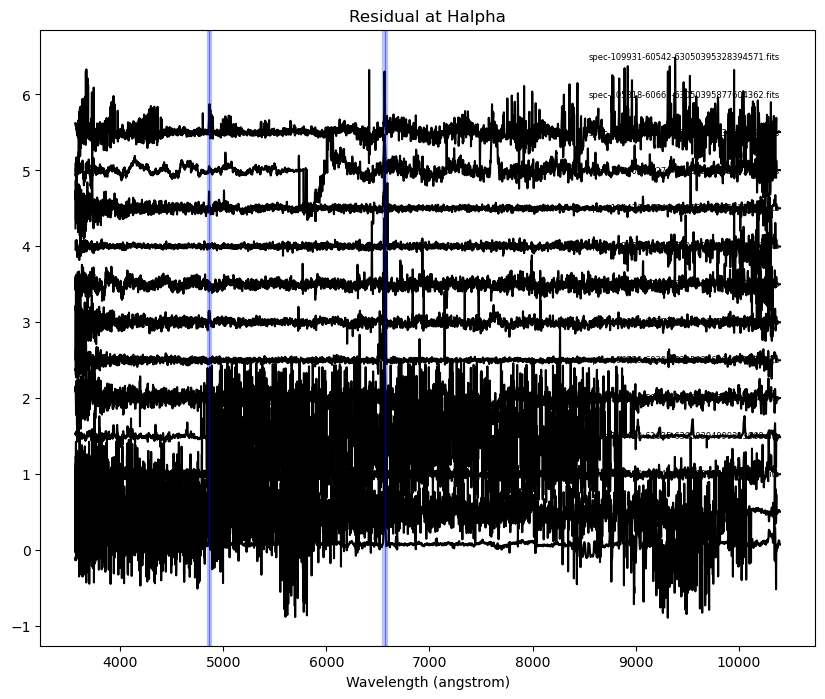

In [74]:
#sort the synthesized 
foo = np.argsort(ews[:, 0])[::-1]
f = plt.figure(figsize=(10, 8))
offset = 0.5
for i in range(12):
    f.gca().plot(wave, data[Bindx[foo[i]]] + i * offset - synth_B[foo[i]], color="k")

plt.axvline(H_ALPHA, lw=1, alpha=0.5, color="b")
plt.axvline(H_BETA, lw=1, alpha=0.5, color="b")
plt.xlabel("Wavelength (angstrom)")
#plt.xlim(H_ALPHA - 200., H_ALPHA + 200.)
halpha_lo = 10**(log_H_ALPHA - H_delta_loglam_line)
halpha_hi = 10**(log_H_ALPHA + H_delta_loglam_line)
plt.axvspan(halpha_lo, halpha_hi, color='royalblue', alpha=0.3)
hbeta_lo = 10**(log_H_BETA - H_delta_loglam_line)
hbeta_hi = 10**(log_H_BETA + H_delta_loglam_line)
plt.axvspan(hbeta_lo, hbeta_hi, color='royalblue', alpha=0.3)
plt.title("Residual at Halpha")
plt.savefig("resid_halpha.png")
plt.show()

## Sorted by highest EW, synthesized spectra

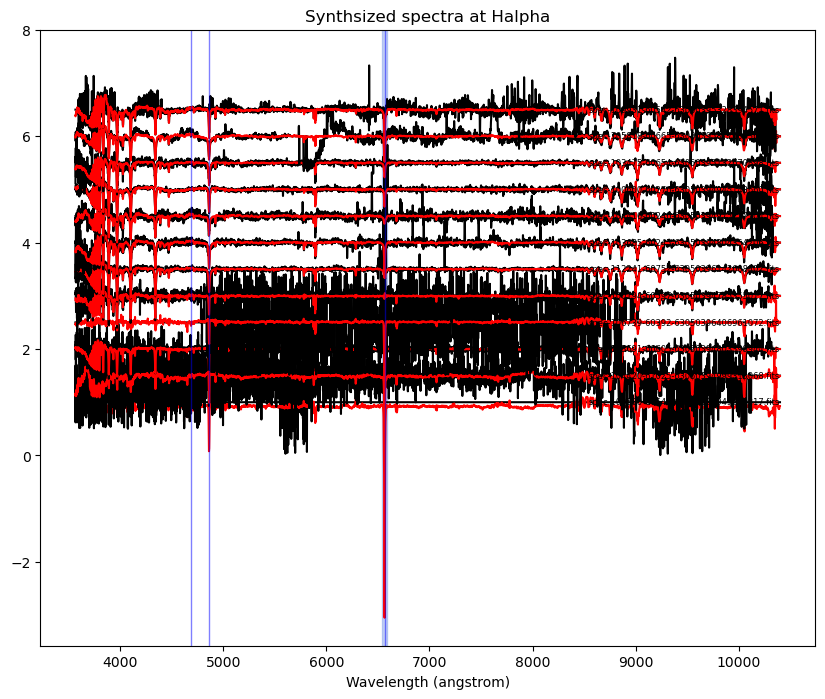

In [83]:
# look at a few spectra and syntheses

f = plt.figure(figsize=(10, 8))
offset = 0.5
ax = f.gca()
for i in range(12):
    ax.plot(wave, data[Bindx[foo[i]]] + i * offset, color="k")
    ax.plot(wave, synth_B[foo[i]] + i * offset, color="r")
    fname = spec_files[Bindx[foo[i]]]
    ax.text(wave[-1], i * offset + 1, fname, fontsize=6, ha='right', va='center')
    

# f = plt.figure(figsize=(10, 8))
# offset = 0.5
# for i in range(12):
#     f.gca().plot(wave, data[Bindx[foo[i]]] + i * offset, color="k")
#     f.gca().plot(wave, synth_B[foo[i]] + i * offset, color="r")
#     fname = spec_files[Bindx[foo[i]]]
#     print("filename:", fname)
#     plt.text(wave[-1], i * offset + 1, fname, fontsize=6, ha='right', va='center')

# f = plt.figure(figsize=(10, 8))
# ax = f.gca()
# offset = 0.5
# for i in range(12):
#     ax.plot(wave, data[Bindx[foo[i]]] + i * offset, color="k")
#     ax.plot(wave, synth_B[foo[i]] + i * offset, color="r")
#     fname = spec_files[Bindx[foo[i]]]
#     ax.text(1.01, (i * offset + 1 - ax.get_ylim()[0]) / (ax.get_ylim()[1] - ax.get_ylim()[0]),
#             fname, fontsize=6, ha='left', va='center', transform=ax.transAxes,
#             bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1))

plt.axvline(H_ALPHA, lw=1, alpha=0.5, color="b")
plt.axvline(H_BETA, lw=1, alpha=0.5, color="b")
plt.axvline(HE_II, lw=1, alpha=0.5, color="b")
plt.xlabel("Wavelength (angstrom)")
#plt.xlim(H_ALPHA - 200, H_ALPHA + 200) 
halpha_lo = 10**(log_H_ALPHA - H_delta_loglam_line)
halpha_hi = 10**(log_H_ALPHA + H_delta_loglam_line)
plt.axvspan(halpha_lo, halpha_hi, color='royalblue', alpha=0.3)
plt.title("Synthsized spectra at Halpha")
#plt.savefig("synth_halpha.png")
plt.show()

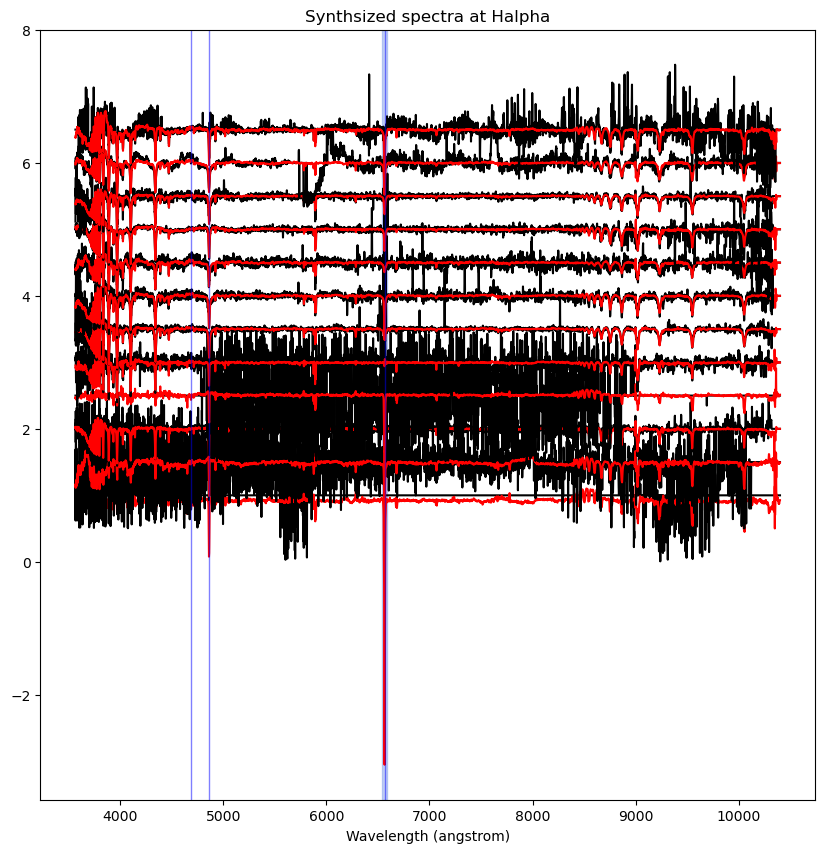

In [63]:
# look at a few spectra and syntheses
f = plt.figure(figsize=(10, 10))
offset = 0.5
for i in range(12):
    f.gca().plot(wave, data[Bindx[foo[i]]] + i * offset, color="k")
    f.gca().plot(wave, synth_B[foo[i]] + i * offset, color="r")

plt.axvline(H_ALPHA, lw=1, alpha=0.5, color="b")
plt.axvline(H_BETA, lw=1, alpha=0.5, color="b")
plt.axvline(HE_II, lw=1, alpha=0.5, color="b")
plt.xlabel("Wavelength (angstrom)")
#plt.xlim(H_ALPHA - 200, H_ALPHA + 200) 
halpha_lo = 10**(log_H_ALPHA - H_delta_loglam_line)
halpha_hi = 10**(log_H_ALPHA + H_delta_loglam_line)
plt.axvspan(halpha_lo, halpha_hi, color='royalblue', alpha=0.3)
plt.title("Synthsized spectra at Halpha")
#plt.savefig("synth_halpha.png")
plt.show()